# Cats vs Dogs Binary Image Classification with CNN

## Complete Production-Ready Deep Learning Pipeline

This notebook takes you from raw image data → trained CNN model → evaluation → deployment-ready application.

**Goals:**
- Build and train a CNN to classify images of cats and dogs
- Evaluate model performance
- Save the trained model
- Prepare for deployment

**Time Estimate:** 20-30 minutes (including training)

## 1. Setup & Imports

In [1]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

2026-03-31 23:10:40.165476: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774998640.416892      94 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774998640.485060      94 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774998641.092473      94 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774998641.092519      94 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774998641.092522      94 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
Keras version: 3.10.0
GPU Available: []


2026-03-31 23:11:13.312980: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Set Configuration Parameters

In [2]:
# Configuration
CONFIG = {
    'dataset_path': '/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages',
    'image_size': (128, 128),
    'batch_size': 32,
    'epochs': 10,
    'validation_split': 0.2,
    'seed': 42,
    'model_save_path': './models/cats_dogs_cnn_model.h5',
    'model_save_path_keras': './models/cats_dogs_cnn_model.keras'
}

# Create model directory
os.makedirs(os.path.dirname(CONFIG['model_save_path']), exist_ok=True)

# Set random seeds for reproducibility
np.random.seed(CONFIG['seed'])
tf.random.set_seed(CONFIG['seed'])

print("Configuration set:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration set:
  dataset_path: /kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages
  image_size: (128, 128)
  batch_size: 32
  epochs: 10
  validation_split: 0.2
  seed: 42
  model_save_path: ./models/cats_dogs_cnn_model.h5
  model_save_path_keras: ./models/cats_dogs_cnn_model.keras


## 3. Data Exploration & Validation

In [3]:
# Check dataset structure
dataset_path = CONFIG['dataset_path']

if os.path.exists(dataset_path):
    cats_dir = os.path.join(dataset_path, 'cats')
    dogs_dir = os.path.join(dataset_path, 'dogs')
    
    if os.path.exists(cats_dir) and os.path.exists(dogs_dir):
        cats_count = len([f for f in os.listdir(cats_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
        dogs_count = len([f for f in os.listdir(dogs_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
        
        print(f"Dataset Found!")
        print(f"  Cats images: {cats_count}")
        print(f"  Dogs images: {dogs_count}")
        print(f"  Total images: {cats_count + dogs_count}")
    else:
        print("⚠️  Dataset structure not found. Expected:")
        print("   ./dataset/cats/")
        print("   ./dataset/dogs/")
else:
    print("⚠️  Dataset directory not found at:", dataset_path)
    print("\nPlease ensure your dataset is organized as:")
    print("  dataset/")
    print("    cats/  (cat images)")
    print("    dogs/  (dog images)")

⚠️  Dataset structure not found. Expected:
   ./dataset/cats/
   ./dataset/dogs/


## 4. Data Loading & Preprocessing

In [4]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=CONFIG['validation_split'],
    fill_mode='nearest'
)

# Test/validation data (only rescaling, no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_data = train_datagen.flow_from_directory(
    CONFIG['dataset_path'],
    target_size=CONFIG['image_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='binary',
    subset='training',
    seed=CONFIG['seed']
)

# Load validation data
val_data = train_datagen.flow_from_directory(
    CONFIG['dataset_path'],
    target_size=CONFIG['image_size'],
    batch_size=CONFIG['batch_size'],
    class_mode='binary',
    subset='validation',
    seed=CONFIG['seed']
)

print(f"Training samples: {train_data.samples}")
print(f"Validation samples: {val_data.samples}")
print(f"Classes: {train_data.class_indices}")

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Training samples: 20000
Validation samples: 4998
Classes: {'Cat': 0, 'Dog': 1}


## 5. Visualize Sample Data

Sample training images:


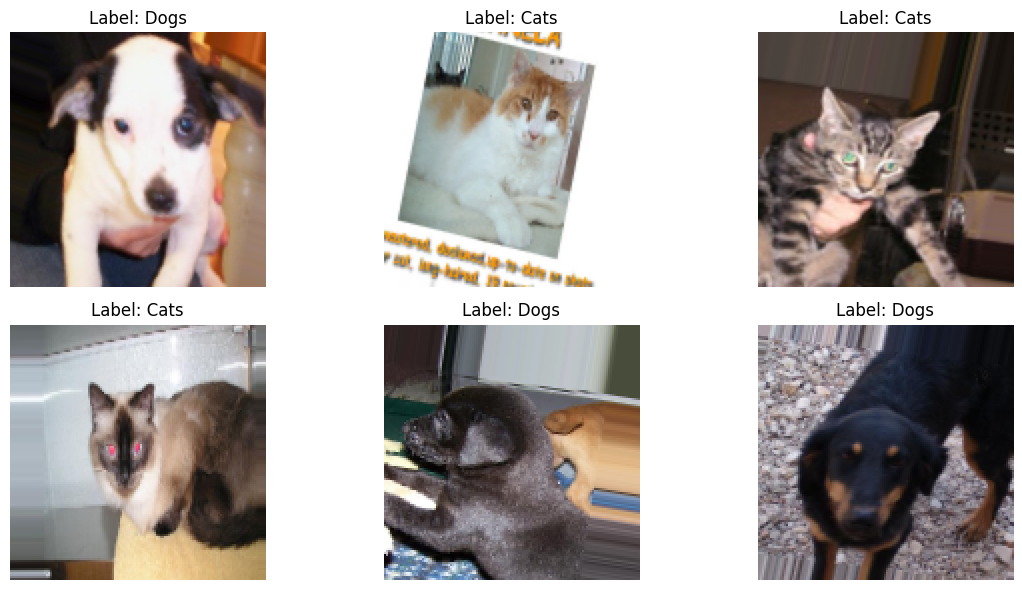

In [5]:
# Visualize sample images from training data
def plot_sample_images(data_generator, num_samples=6):
    images, labels = next(iter(data_generator))
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.flatten()
    
    class_names = ['Cats', 'Dogs']
    
    for i in range(min(num_samples, len(images))):
        axes[i].imshow(images[i])
        axes[i].set_title(f"Label: {class_names[int(labels[i])]}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Sample training images:")
plot_sample_images(train_data)

## 6. Build CNN Model

In [6]:
# Build the CNN model
def create_cnn_model(input_shape=(128, 128, 3)):
    """
    Create a simple but effective CNN for binary image classification.
    
    Architecture:
    - Conv2D layers with ReLU activation for feature extraction
    - MaxPooling layers for dimensionality reduction
    - Dropout layers for regularization
    - Dense layers for classification
    """
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Flatten and Dense layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        
        # Output layer (binary classification)
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

# Create model
model = create_cnn_model()

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("Model Architecture:")
model.summary()

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,549,057 (24.98 MB)

 Trainable params: 6,549,057 (24.98 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model

In [7]:
# Train the model
print("Starting training...\n")

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=CONFIG['epochs'],
    verbose=1,
    steps_per_epoch=len(train_data),
    validation_steps=len(val_data)
)

print("\nTraining completed!")

Starting training...

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 482s 767ms/step - accuracy: 0.5015 - loss: 0.7150 - val_accuracy: 0.5478 - val_loss: 0.6927
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 389s 622ms/step - accuracy: 0.5430 - loss: 0.6883 - val_accuracy: 0.5702 - val_loss: 0.6787
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 437s 613ms/step - accuracy: 0.5631 - loss: 0.6819 - val_accuracy: 0.5348 - val_loss: 0.6955
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 383s 612ms/step - accuracy: 0.5699 - loss: 0.6827 - val_accuracy: 0.6357 - val_loss: 0.6475
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 444s 616ms/step - accuracy: 0.5895 - loss: 0.6693 - val_accuracy: 0.6058 - val_loss: 0.6493
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 487s 689ms/step - accuracy: 0.6354 - loss: 0.6409 - val_accuracy: 0.6703 - val_loss: 0.5967
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 385s 616ms/step - accuracy: 0.6743 - loss: 0.6056 - val_accuracy: 0.7059 - val_loss: 0.5760
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 391s 625ms/ste

## 8. Visualize Training History

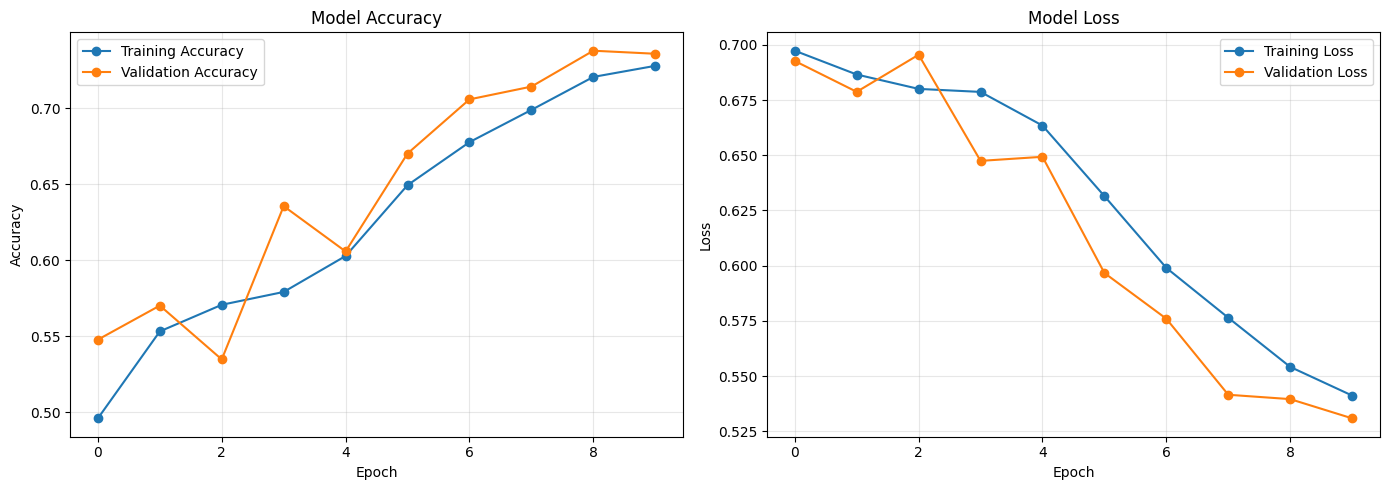

Final Training Accuracy: 0.7279
Final Validation Accuracy: 0.7359


In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

## 9. Model Evaluation

In [9]:
# Evaluate model on validation data
val_loss, val_accuracy = model.evaluate(val_data)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Get predictions on validation set
val_data.reset()
y_pred_proba = model.predict(val_data)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = val_data.classes[:len(y_pred)]

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Cats', 'Dogs']))

157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 286ms/step - accuracy: 0.7437 - loss: 0.5274
Validation Loss: 0.5260
Validation Accuracy: 0.7385
157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 284ms/step

Classification Report:
              precision    recall  f1-score   support

        Cats       0.50      0.65      0.57      2499
        Dogs       0.50      0.34      0.41      2499

    accuracy                           0.50      4998
   macro avg       0.50      0.50      0.49      4998
weighted avg       0.50      0.50      0.49      4998



## 10. Confusion Matrix

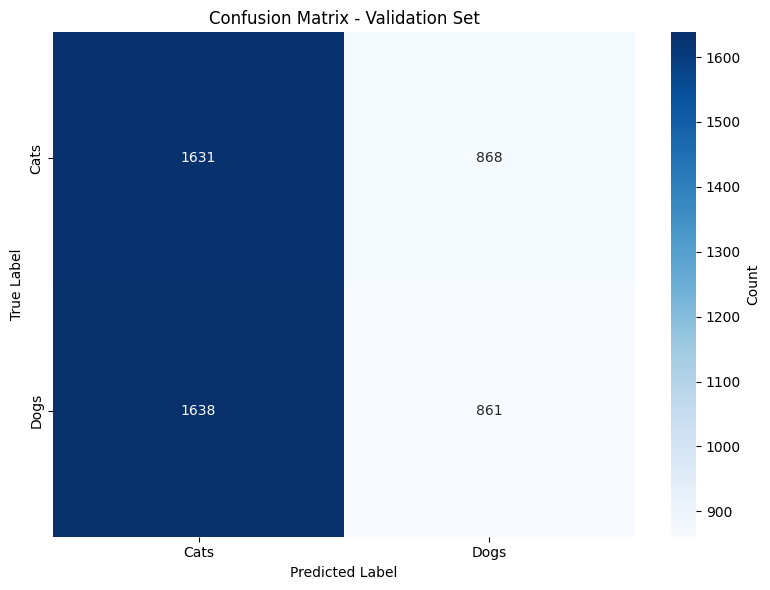


True Negatives (Correct Cats): 1631
False Positives (Cats→Dogs): 868
False Negatives (Dogs→Cats): 1638
True Positives (Correct Dogs): 861


In [10]:
# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cats', 'Dogs'],
            yticklabels=['Cats', 'Dogs'],
            cbar_kws={'label': 'Count'})
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (Correct Cats): {cm[0, 0]}")
print(f"False Positives (Cats→Dogs): {cm[0, 1]}")
print(f"False Negatives (Dogs→Cats): {cm[1, 0]}")
print(f"True Positives (Correct Dogs): {cm[1, 1]}")

## 11. Save the Trained Model

In [11]:
# Save model in both formats for compatibility
model.save(CONFIG['model_save_path'])
model.save(CONFIG['model_save_path_keras'])

print(f"✓ Model saved to: {CONFIG['model_save_path']}")
print(f"✓ Model saved to: {CONFIG['model_save_path_keras']}")

# Display model info
print(f"\nModel Info:")
print(f"  Total Parameters: {model.count_params():,}")
print(f"  Input Shape: {model.input_shape}")
print(f"  Output Shape: {model.output_shape}")

✓ Model saved to: ./models/cats_dogs_cnn_model.h5
✓ Model saved to: ./models/cats_dogs_cnn_model.keras

Model Info:
  Total Parameters: 6,549,057
  Input Shape: (None, 128, 128, 3)
  Output Shape: (None, 1)


## 12. Test Predictions on Custom Images

In [12]:
# Function to predict on custom image
def predict_image(image_path, model, image_size=(128, 128)):
    """
    Load an image and make a prediction.
    
    Returns:
        prediction: 'Cat' or 'Dog'
        confidence: probability score
    """
    try:
        # Load and preprocess image
        img = load_img(image_path, target_size=image_size)
        img_array = img_to_array(img) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        
        # Make prediction
        prediction = model.predict(img_batch, verbose=0)[0][0]
        
        # Interpret result (0 = Cat, 1 = Dog)
        label = 'Dog' if prediction > 0.5 else 'Cat'
        confidence = prediction if prediction > 0.5 else (1 - prediction)
        
        return label, float(confidence)
    except Exception as e:
        print(f"Error predicting image: {e}")
        return None, None

# Test on a sample image from validation set
print("Testing predictions on validation samples...\n")

cats_dir = os.path.join(CONFIG['dataset_path'], 'cats')
dogs_dir = os.path.join(CONFIG['dataset_path'], 'dogs')

test_images = []
if os.path.exists(cats_dir):
    cat_files = [f for f in os.listdir(cats_dir) if f.endswith(('.jpg', '.jpeg', '.png'))][:2]
    test_images.extend([(os.path.join(cats_dir, f), 'Cat') for f in cat_files])

if os.path.exists(dogs_dir):
    dog_files = [f for f in os.listdir(dogs_dir) if f.endswith(('.jpg', '.jpeg', '.png'))][:2]
    test_images.extend([(os.path.join(dogs_dir, f), 'Dog') for f in dog_files])

if test_images:
    fig, axes = plt.subplots(1, min(4, len(test_images)), figsize=(14, 4))
    if len(test_images) == 1:
        axes = [axes]
    
    for idx, (image_path, true_label) in enumerate(test_images[:4]):
        pred_label, confidence = predict_image(image_path, model)
        
        img = imread(image_path)
        axes[idx].imshow(img)
        
        color = 'green' if pred_label == true_label else 'red'
        axes[idx].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2%})", color=color)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No test images found. Ensure dataset is properly organized.")

Testing predictions on validation samples...

No test images found. Ensure dataset is properly organized.


## 13. Summary & Next Steps

In [15]:
print("\n" + "="*60)
print("TRAINING PIPELINE COMPLETED!")
print("="*60)

print(f"\n✓ Model trained with {CONFIG['epochs']} epochs")
print(f"✓ Final validation accuracy: {history.history['val_accuracy'][-1]:.2%}")
print(f"✓ Model saved to: {CONFIG['model_save_path']}")

print("\n📦 NEXT STEPS - DEPLOYMENT:")
print("\n1. Use the saved model for inference")
print("2. Run the Streamlit app (recommended):")
print("   $ streamlit run app.py")
print("\n3. Or run the Flask app:")
print("   $ python app_flask.py")

print("\n🚀 CLOUD DEPLOYMENT OPTIONS (Free Tier):")
print("   - Streamlit Cloud (streamlit.io) - Free")
print("   - Heroku with Flask - Free tier available")
print("   - Google Colab - Free GPU")

print("\n📊 FILES GENERATED:")
print(f"   - Model: {CONFIG['model_save_path']}")
print(f"   - Model (Keras): {CONFIG['model_save_path_keras']}")
print("\n" + "="*60)


TRAINING PIPELINE COMPLETED!

✓ Model trained with 10 epochs
✓ Final validation accuracy: 73.59%
✓ Model saved to: ./models/cats_dogs_cnn_model.h5

📦 NEXT STEPS - DEPLOYMENT:

1. Use the saved model for inference
2. Run the Streamlit app (recommended):
   $ streamlit run app.py

3. Or run the Flask app:
   $ python app_flask.py

🚀 CLOUD DEPLOYMENT OPTIONS (Free Tier):
   - Streamlit Cloud (streamlit.io) - Free
   - Heroku with Flask - Free tier available
   - Google Colab - Free GPU

📊 FILES GENERATED:
   - Model: ./models/cats_dogs_cnn_model.h5
   - Model (Keras): ./models/cats_dogs_cnn_model.keras

